In [63]:
import pandas as pd
data=pd.read_csv("dataset_cleaned.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   school_type                 100000 non-null  object 
 5   family_income               100000 non-null  object 
 6   parent_education            100000 non-null  object 
 7   urban_rural                 100000 non-null  object 
 8   previous_exam_score         100000 non-null  float64
 9   previous_gpa                100000 non-null  float64
 10  attendance_percentage       100000 non-null  float64
 11  assignment_completion_rate  100000 non-null  float64
 12  class_participation         100000 non-null  object 
 13  study_hours_per

In [64]:
data["exam_score"]

0        90.40
1        86.21
2        76.11
3        79.74
4        50.66
         ...  
99995    66.46
99996    96.54
99997    74.66
99998    85.85
99999    54.40
Name: exam_score, Length: 100000, dtype: float64

In [65]:
Y=data["exam_score"]
X = data.drop(columns=['exam_score'])
X

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,Inconnu,Rural,78.36,2.95,...,2.15,Medium,27,95,86,79.00,9.39,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,Inconnu,Suburban,73.40,2.89,...,4.37,Easy,4,100,86,87.17,6.31,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,...,1.43,Easy,28,96,74,63.77,9.87,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,...,3.69,Medium,16,97,77,59.51,9.68,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,...,1.97,Medium,28,98,52,84.64,10.00,D,Pass,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU_099996,17,Male,Undergraduate,Public,Upper-Middle,Inconnu,Suburban,78.73,2.78,...,6.43,Medium,5,95,62,76.13,8.36,C,Pass,Medium
99996,STU_099997,14,Female,High School,Public,Upper-Middle,Bachelor,Suburban,75.70,2.98,...,4.34,Easy,24,94,91,84.29,8.68,A,Pass,High
99997,STU_099998,16,Female,High School,Public,Upper-Middle,High School,Suburban,84.69,3.27,...,11.91,Medium,24,85,65,62.32,9.97,C,Pass,Medium
99998,STU_099999,15,Female,High School,Private,High,Master,Rural,74.70,3.06,...,0.55,Medium,28,93,81,100.00,10.00,A,Pass,High


In [66]:
cols_num = X.select_dtypes(include=['int64', 'float64']).columns
print(cols_num)

Index(['age', 'previous_exam_score', 'previous_gpa', 'attendance_percentage',
       'assignment_completion_rate', 'study_hours_per_day', 'self_study_hours',
       'private_tuition', 'online_learning_hours', 'practice_tests_completed',
       'sleep_hours', 'daily_screen_time', 'physical_activity_hours',
       'stress_level', 'internet_access', 'online_course_hours',
       'exam_preparation_days', 'questions_attempted', 'questions_correct',
       'time_management_score', 'exam_anxiety_level'],
      dtype='object')


In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[cols_num] = scaler.fit_transform(data[cols_num])
X

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,performance_grade,pass_status,performance_level
0,STU_000001,1.497466,Female,High School,Public,Middle,Inconnu,Rural,0.775897,0.368415,...,-0.284696,Medium,1.330188,0.544078,1.909795,0.040536,0.341456,A,Pass,High
1,STU_000002,-0.002871,Male,High School,Public,Middle,Inconnu,Suburban,0.340008,0.237754,...,0.459342,Easy,-1.330521,1.628829,1.909795,0.649730,-1.931829,A,Pass,High
2,STU_000003,0.497241,Other,Undergraduate,Public,Middle,Master,Urban,1.162572,1.239489,...,-0.526006,Easy,1.445871,0.761029,1.111323,-1.095085,0.695734,B,Pass,Medium
3,STU_000004,1.497466,Male,High School,Public,Middle,High School,Suburban,-0.783987,-0.459105,...,0.231438,Medium,0.057675,0.977979,1.310941,-1.412731,0.555499,B,Pass,Medium
4,STU_000005,-0.502983,Female,High School,Private,High,Bachelor,Suburban,0.462162,0.128870,...,-0.345024,Medium,1.445871,1.194929,-0.352541,0.461081,0.791684,D,Pass,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU_099996,-0.002871,Male,Undergraduate,Public,Upper-Middle,Inconnu,Suburban,0.808412,-0.001791,...,1.149756,Medium,-1.214838,0.544078,0.312852,-0.173465,-0.418766,C,Pass,Medium
99996,STU_099997,-1.503207,Female,High School,Public,Upper-Middle,Bachelor,Suburban,0.542134,0.433746,...,0.449288,Easy,0.983139,0.327128,2.242492,0.434983,-0.182581,A,Pass,High
99997,STU_099998,-0.502983,Female,High School,Public,Upper-Middle,High School,Suburban,1.332182,1.065274,...,2.986391,Medium,0.983139,-1.625423,0.512470,-1.203204,0.769542,C,Pass,Medium
99998,STU_099999,-1.003095,Female,High School,Private,High,Master,Rural,0.454253,0.607960,...,-0.820940,Medium,1.445871,0.110178,1.577099,1.606396,0.791684,A,Pass,High


In [68]:
cols_binaires = [
    col for col in X.select_dtypes(include=['object', 'category']).columns 
    if X[col].nunique() == 2
]
X[cols_binaires]

,education_level,pass_status
0,High School,Pass
1,High School,Pass
2,Undergraduate,Pass
3,High School,Pass
4,High School,Pass
...,...,...
99995,Undergraduate,Pass
99996,High School,Pass
99997,High School,Pass
99998,High School,Pass


In [69]:

ordre_education = {
    'High School': 1,
    'Undergraduate': 2
    }
X['education_level'] = data['education_level'].map(ordre_education)
scaler = StandardScaler()
X['education_level'] = scaler.fit_transform(X[['education_level']])
X["education_level"]


0       -0.820722
1       -0.820722
2        1.218440
3       -0.820722
4       -0.820722
           ...   
99995    1.218440
99996   -0.820722
99997   -0.820722
99998   -0.820722
99999    1.218440
Name: education_level, Length: 100000, dtype: float64

In [70]:

statue_ordre={
 'Fail': 1,
 'Pass': 2
}
X['pass_status'] = data['pass_status'].map(statue_ordre)
scaler = StandardScaler()
X['pass_status'] = scaler.fit_transform(X[['pass_status']])
X["pass_status"]


0        0.540531
1        0.540531
2        0.540531
3        0.540531
4        0.540531
           ...   
99995    0.540531
99996    0.540531
99997    0.540531
99998    0.540531
99999    0.540531
Name: pass_status, Length: 100000, dtype: float64

In [71]:
cols_cat= X.select_dtypes(include=['object']).columns
print(cols_cat)

Index(['student_id', 'gender', 'school_type', 'family_income',
       'parent_education', 'urban_rural', 'class_participation',
       'study_consistency', 'study_environment', 'study_method',
       'revision_frequency', 'notes_quality', 'sleep_quality',
       'break_frequency', 'motivation_level', 'device_availability',
       'educational_app_usage', 'exam_difficulty', 'performance_grade',
       'performance_level'],
      dtype='object')


In [72]:
X=X.drop(columns="student_id")
X

,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,attendance_percentage,...,online_course_hours,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,performance_grade,pass_status,performance_level
0,1.497466,Female,-0.820722,Public,Middle,Inconnu,Rural,0.775897,0.368415,-0.417460,...,-0.284696,Medium,1.330188,0.544078,1.909795,0.040536,0.341456,A,0.540531,High
1,-0.002871,Male,-0.820722,Public,Middle,Inconnu,Suburban,0.340008,0.237754,0.015952,...,0.459342,Easy,-1.330521,1.628829,1.909795,0.649730,-1.931829,A,0.540531,High
2,0.497241,Other,1.218440,Public,Middle,Master,Urban,1.162572,1.239489,2.043417,...,-0.526006,Easy,1.445871,0.761029,1.111323,-1.095085,0.695734,B,0.540531,Medium
3,1.497466,Male,-0.820722,Public,Middle,High School,Suburban,-0.783987,-0.459105,0.037224,...,0.231438,Medium,0.057675,0.977979,1.310941,-1.412731,0.555499,B,0.540531,Medium
4,-0.502983,Female,-0.820722,Private,High,Bachelor,Suburban,0.462162,0.128870,0.475954,...,-0.345024,Medium,1.445871,1.194929,-0.352541,0.461081,0.791684,D,0.540531,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-0.002871,Male,1.218440,Public,Upper-Middle,Inconnu,Suburban,0.808412,-0.001791,0.670059,...,1.149756,Medium,-1.214838,0.544078,0.312852,-0.173465,-0.418766,C,0.540531,Medium
99996,-1.503207,Female,-0.820722,Public,Upper-Middle,Bachelor,Suburban,0.542134,0.433746,-0.101042,...,0.449288,Easy,0.983139,0.327128,2.242492,0.434983,-0.182581,A,0.540531,High
99997,-0.502983,Female,-0.820722,Public,Upper-Middle,High School,Suburban,1.332182,1.065274,0.656764,...,2.986391,Medium,0.983139,-1.625423,0.512470,-1.203204,0.769542,C,0.540531,Medium
99998,-1.003095,Female,-0.820722,Private,High,Master,Rural,0.454253,0.607960,1.060927,...,-0.820940,Medium,1.445871,0.110178,1.577099,1.606396,0.791684,A,0.540531,High


In [73]:

income_mapping = {
    'Low': 1,
    'Lower-Middle': 2,
    'Middle': 3,
    'Upper-Middle': 4,
    'High': 5
}
X['family_income'] = X['family_income'].map(income_mapping)
scaler = StandardScaler()
X['family_income'] = scaler.fit_transform(X[['family_income']])
X["family_income"]

0        0.241293
1        0.241293
2        0.241293
3        0.241293
4        1.869617
           ...   
99995    1.055455
99996    1.055455
99997    1.055455
99998    1.869617
99999   -0.572869
Name: family_income, Length: 100000, dtype: float64

In [74]:

education_mapping = {
    'Inconnu': 0,
    'High School': 1,
    'Associate': 2,    
    'Bachelor': 3,     
    'Master': 4,      
    'Doctorate': 5     
}
X['parent_education'] = X['parent_education'].map(education_mapping)
scaler = StandardScaler()
X['parent_education'] = scaler.fit_transform(X[['parent_education']])
X["parent_education"]

0       -1.744101
1       -1.744101
2        1.301925
3       -0.982595
4        0.540418
           ...   
99995   -1.744101
99996    0.540418
99997   -0.982595
99998    1.301925
99999   -1.744101
Name: parent_education, Length: 100000, dtype: float64

In [75]:

urban_mapping = {
    'Rural': 1,
    'Suburban': 2,
    'Urban': 3
}


X['urban_rural'] = X['urban_rural'].map(urban_mapping)
scaler = StandardScaler()
X['urban_rural'] = scaler.fit_transform(X[['urban_rural']])
X["urban_rural"]

0       -1.634124
1       -0.327525
2        0.979073
3       -0.327525
4       -0.327525
           ...   
99995   -0.327525
99996   -0.327525
99997   -0.327525
99998   -1.634124
99999    0.979073
Name: urban_rural, Length: 100000, dtype: float64

In [76]:

participation_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
X['class_participation'] = X['class_participation'].map(participation_mapping)
scaler = StandardScaler()
X['class_participation'] = scaler.fit_transform(X[['class_participation']])
X["class_participation"]

0        0.005819
1       -1.409963
2        0.005819
3       -1.409963
4        0.005819
           ...   
99995    1.421600
99996    0.005819
99997    0.005819
99998    0.005819
99999    0.005819
Name: class_participation, Length: 100000, dtype: float64

In [77]:

study_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
X['study_consistency'] = X['study_consistency'].map(study_mapping)
scaler = StandardScaler()
X['study_consistency'] = scaler.fit_transform(X[['study_consistency']])
X["study_consistency"]


0       -0.069035
1       -0.069035
2       -1.565575
3       -0.069035
4       -0.069035
           ...   
99995   -0.069035
99996   -0.069035
99997    1.427504
99998   -0.069035
99999   -0.069035
Name: study_consistency, Length: 100000, dtype: float64

In [78]:

environment_mapping = {
    'Noisy': 1,
    'Moderate': 2,
    'Quiet': 3
}


X['study_environment'] = X['study_environment'].map(environment_mapping)
scaler = StandardScaler()
X['study_environment'] = scaler.fit_transform(X[['study_environment']])
X["study_environment"]

0       -0.479886
1       -0.479886
2       -0.479886
3        0.898424
4       -1.858197
           ...   
99995   -0.479886
99996   -1.858197
99997   -0.479886
99998    0.898424
99999   -0.479886
Name: study_environment, Length: 100000, dtype: float64

In [79]:

frequency_mapping = {
    'Rarely': 1,
    'Weekly': 2,
    'Daily': 3
}
X['revision_frequency'] = X['revision_frequency'].map(frequency_mapping)
scaler = StandardScaler()
X['revision_frequency'] = scaler.fit_transform(X[['revision_frequency']])
X["revision_frequency"]

0       -1.571585
1        1.282547
2       -0.144519
3       -0.144519
4       -1.571585
           ...   
99995   -0.144519
99996   -0.144519
99997   -1.571585
99998   -0.144519
99999   -0.144519
Name: revision_frequency, Length: 100000, dtype: float64

In [80]:

notes_mapping = {
    'Inconnu': 0,
    'Poor': 1,
    'Average': 2,
    'Excellent': 3
}

X['notes_quality'] = X['notes_quality'].map(notes_mapping)

scaler = StandardScaler()
X['notes_quality'] = scaler.fit_transform(X[['notes_quality']])
X["notes_quality"]

0        0.202744
1        0.202744
2        1.420136
3        1.420136
4       -1.014647
           ...   
99995    0.202744
99996   -2.232039
99997    0.202744
99998    0.202744
99999    0.202744
Name: notes_quality, Length: 100000, dtype: float64

In [81]:

sleep_mapping = {
    'Inconnu': 0,
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Excellent': 4
}
X['sleep_quality'] = X['sleep_quality'].map(sleep_mapping)
X['sleep_quality'] = scaler.fit_transform(X[['sleep_quality']])
X["sleep_quality"]

0        1.526094
1        1.526094
2       -1.208956
3       -0.297273
4        1.526094
           ...   
99995   -0.297273
99996    1.526094
99997   -0.297273
99998   -1.208956
99999    0.614411
Name: sleep_quality, Length: 100000, dtype: float64

In [82]:

break_mapping = {
    'Rarely': 1,
    'Occasionally': 2,
    'Frequently': 3
}

X['break_frequency'] = X['break_frequency'].map(break_mapping)

scaler = StandardScaler()
X['break_frequency'] = scaler.fit_transform(X[['break_frequency']])
X["break_frequency"]

0        1.281146
1        1.281146
2       -1.573521
3       -1.573521
4        1.281146
           ...   
99995   -0.146188
99996    1.281146
99997   -0.146188
99998   -1.573521
99999   -1.573521
Name: break_frequency, Length: 100000, dtype: float64

In [83]:

motivation_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

X['motivation_level'] = X['motivation_level'].map(motivation_mapping)

scaler = StandardScaler()
X['motivation_level'] = scaler.fit_transform(X[['motivation_level']])
X["motivation_level"]

0        1.279983
1        1.279983
2       -0.146166
3        1.279983
4        1.279983
           ...   
99995   -0.146166
99996   -1.572315
99997   -0.146166
99998   -0.146166
99999   -1.572315
Name: motivation_level, Length: 100000, dtype: float64

In [84]:

device_mapping = {
    'Inconnu': 0,
    'Shared': 1,
    'Dedicated': 2
}

X['device_availability'] = X['device_availability'].map(device_mapping)

scaler = StandardScaler()
X['device_availability'] = scaler.fit_transform(X[['device_availability']])
X["device_availability"]

0       -1.317195
1       -1.317195
2        0.594637
3        0.594637
4        0.594637
           ...   
99995   -1.317195
99996    0.594637
99997    0.594637
99998   -1.317195
99999    0.594637
Name: device_availability, Length: 100000, dtype: float64

In [85]:

app_usage_mapping = {
    'Low': 1,
    'Moderate': 2,
    'High': 3
}

X['educational_app_usage'] = X['educational_app_usage'].map(app_usage_mapping)

scaler = StandardScaler()
X['educational_app_usage'] = scaler.fit_transform(X[['educational_app_usage']])
X["educational_app_usage"]

0       -1.069792
1        0.268251
2       -1.069792
3       -1.069792
4        0.268251
           ...   
99995    1.606293
99996   -1.069792
99997    0.268251
99998    0.268251
99999   -1.069792
Name: educational_app_usage, Length: 100000, dtype: float64

In [86]:

difficulty_mapping = {
    'Easy': 1,
    'Medium': 2,
    'Hard': 3
}

X['exam_difficulty'] = X['exam_difficulty'].map(difficulty_mapping)

scaler = StandardScaler()
X['exam_difficulty'] = scaler.fit_transform(X[['exam_difficulty']])
X["exam_difficulty"]

0       -0.003317
1       -1.420974
2       -1.420974
3       -0.003317
4       -0.003317
           ...   
99995   -0.003317
99996   -1.420974
99997   -0.003317
99998   -0.003317
99999   -0.003317
Name: exam_difficulty, Length: 100000, dtype: float64

In [87]:

grade_mapping = {
    'F': 1,
    'D': 2,
    'C': 3,
    'B': 4,
    'A': 5
}

X['performance_grade'] = X['performance_grade'].map(grade_mapping)

scaler = StandardScaler()
X['performance_grade'] = scaler.fit_transform(X[['performance_grade']])
X["performance_grade"]

0        2.116111
1        2.116111
2        1.275984
3        1.275984
4       -0.404269
           ...   
99995    0.435858
99996    2.116111
99997    0.435858
99998    2.116111
99999   -0.404269
Name: performance_grade, Length: 100000, dtype: float64

In [88]:

level_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

X['performance_level'] = X['performance_level'].map(level_mapping)

scaler = StandardScaler()
X['performance_level'] = scaler.fit_transform(X[['performance_level']])
X["performance_level"]

0        1.916723
1        1.916723
2        0.467350
3        0.467350
4       -0.982023
           ...   
99995    0.467350
99996    1.916723
99997    0.467350
99998    1.916723
99999   -0.982023
Name: performance_level, Length: 100000, dtype: float64

In [90]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         100000 non-null  float64
 1   gender                      100000 non-null  object 
 2   education_level             100000 non-null  float64
 3   school_type                 100000 non-null  object 
 4   family_income               100000 non-null  float64
 5   parent_education            100000 non-null  float64
 6   urban_rural                 100000 non-null  float64
 7   previous_exam_score         100000 non-null  float64
 8   previous_gpa                100000 non-null  float64
 9   attendance_percentage       100000 non-null  float64
 10  assignment_completion_rate  100000 non-null  float64
 11  class_participation         100000 non-null  float64
 12  study_hours_per_day         100000 non-null  float64
 13  self_study_hour

In [97]:


X = pd.get_dummies(X, columns=['school_type'], drop_first=False, dtype=int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         100000 non-null  float64
 1   education_level             100000 non-null  float64
 2   family_income               100000 non-null  float64
 3   parent_education            100000 non-null  float64
 4   urban_rural                 100000 non-null  float64
 5   previous_exam_score         100000 non-null  float64
 6   previous_gpa                100000 non-null  float64
 7   attendance_percentage       100000 non-null  float64
 8   assignment_completion_rate  100000 non-null  float64
 9   class_participation         100000 non-null  float64
 10  study_hours_per_day         100000 non-null  float64
 11  self_study_hours            100000 non-null  float64
 12  private_tuition             100000 non-null  float64
 13  online_learning

In [99]:
X.columns

Index(['age', 'education_level', 'family_income', 'parent_education',
       'urban_rural', 'previous_exam_score', 'previous_gpa',
       'attendance_percentage', 'assignment_completion_rate',
       'class_participation', 'study_hours_per_day', 'self_study_hours',
       'private_tuition', 'online_learning_hours', 'study_consistency',
       'study_environment', 'study_method', 'revision_frequency',
       'practice_tests_completed', 'notes_quality', 'sleep_hours',
       'sleep_quality', 'daily_screen_time', 'physical_activity_hours',
       'break_frequency', 'stress_level', 'motivation_level',
       'internet_access', 'device_availability', 'educational_app_usage',
       'online_course_hours', 'exam_difficulty', 'exam_preparation_days',
       'questions_attempted', 'questions_correct', 'time_management_score',
       'exam_anxiety_level', 'performance_grade', 'pass_status',
       'performance_level', 'gender_Female', 'gender_Male', 'gender_Other',
       'school_type_Charter', 

In [100]:
X = pd.get_dummies(X, columns=['study_method'], drop_first=False, dtype=int)
X.columns

Index(['age', 'education_level', 'family_income', 'parent_education',
       'urban_rural', 'previous_exam_score', 'previous_gpa',
       'attendance_percentage', 'assignment_completion_rate',
       'class_participation', 'study_hours_per_day', 'self_study_hours',
       'private_tuition', 'online_learning_hours', 'study_consistency',
       'study_environment', 'revision_frequency', 'practice_tests_completed',
       'notes_quality', 'sleep_hours', 'sleep_quality', 'daily_screen_time',
       'physical_activity_hours', 'break_frequency', 'stress_level',
       'motivation_level', 'internet_access', 'device_availability',
       'educational_app_usage', 'online_course_hours', 'exam_difficulty',
       'exam_preparation_days', 'questions_attempted', 'questions_correct',
       'time_management_score', 'exam_anxiety_level', 'performance_grade',
       'pass_status', 'performance_level', 'gender_Female', 'gender_Male',
       'gender_Other', 'school_type_Charter', 'school_type_Private',


In [102]:
Y

0        90.40
1        86.21
2        76.11
3        79.74
4        50.66
         ...  
99995    66.46
99996    96.54
99997    74.66
99998    85.85
99999    54.40
Name: exam_score, Length: 100000, dtype: float64

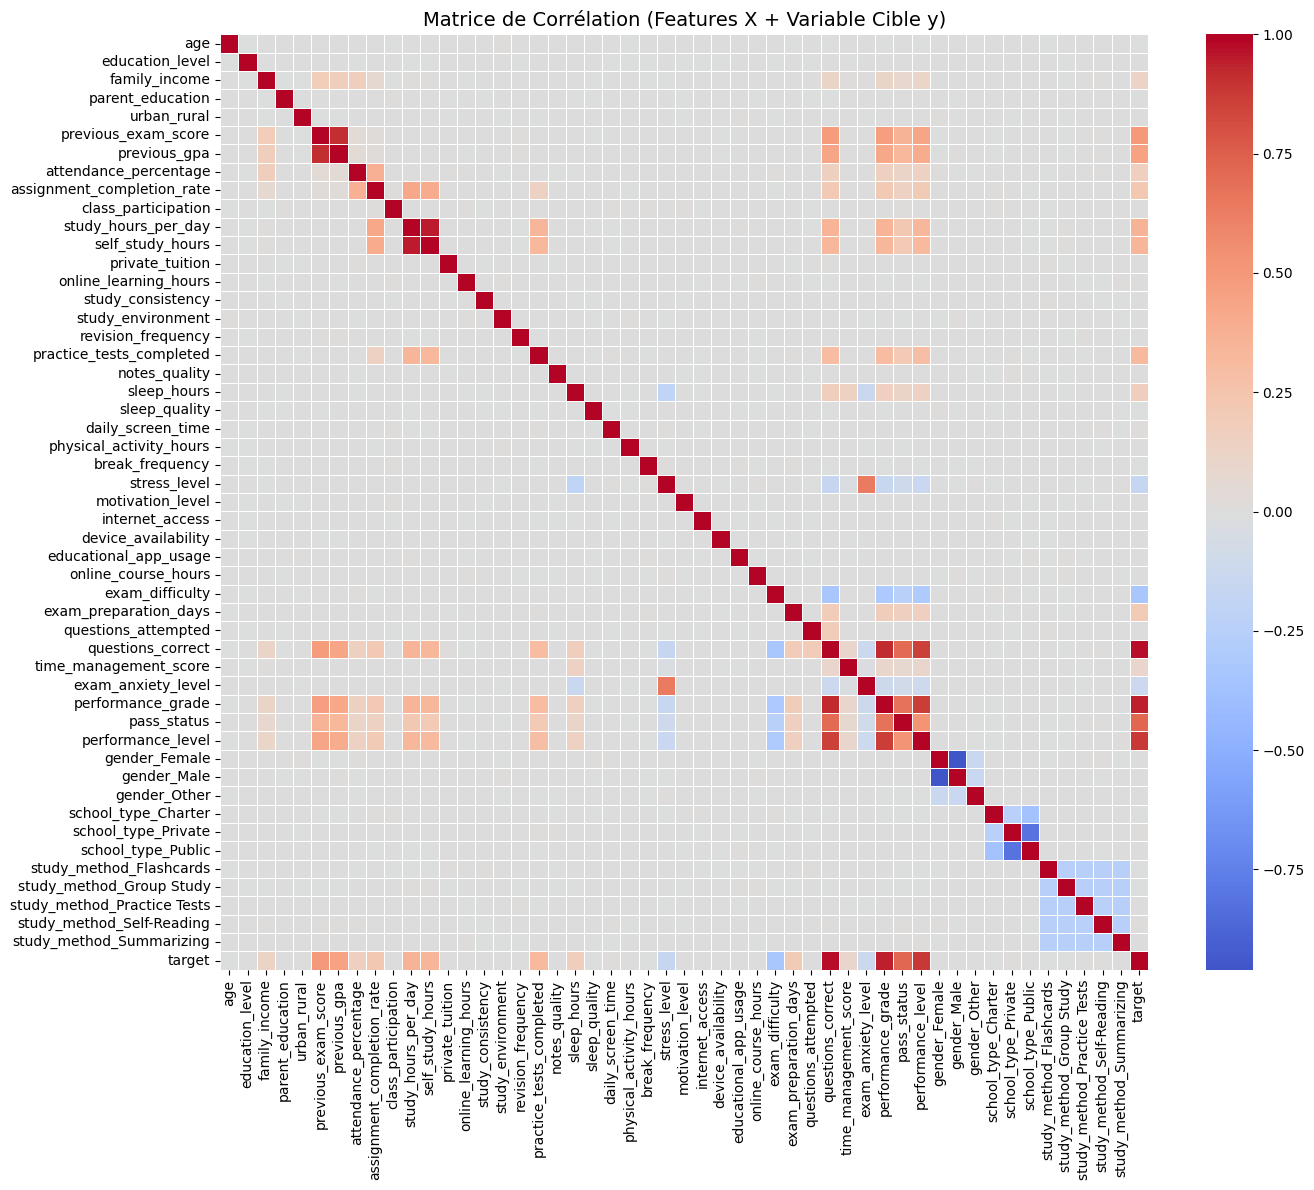

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
df_corr = X.copy()
df_corr['target'] = Y


corr_matrix = df_corr.corr()


plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Matrice de Corrélation (Features X + Variable Cible y)", fontsize=14)
plt.tight_layout()
plt.show()

In [106]:
correlations = df_corr.corr()['target'].drop('target').sort_values(ascending=False)
df_corr_result = correlations.to_frame(name='Correlation_avec_Y')
print(df_corr_result)

                             Correlation_avec_Y
questions_correct                      0.975310
performance_grade                      0.942001
performance_level                      0.879259
pass_status                            0.721851
previous_exam_score                    0.494438
previous_gpa                           0.449751
study_hours_per_day                    0.363243
self_study_hours                       0.342955
practice_tests_completed               0.316475
assignment_completion_rate             0.221118
exam_preparation_days                  0.198577
sleep_hours                            0.170600
attendance_percentage                  0.160720
family_income                          0.121017
time_management_score                  0.101569
study_method_Self-Reading              0.005057
school_type_Private                    0.005021
daily_screen_time                      0.004760
private_tuition                        0.003833
questions_attempted                    0

In [107]:
correlations = df_corr.corr()['target'].drop('target')


seuil = 0.05
features_a_garder = correlations[correlations.abs() >= seuil].index
features_a_supprimer = correlations[correlations.abs() < seuil].index


X = X[features_a_garder]
X

,family_income,previous_exam_score,previous_gpa,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,practice_tests_completed,sleep_hours,stress_level,exam_difficulty,exam_preparation_days,questions_correct,time_management_score,exam_anxiety_level,performance_grade,pass_status,performance_level
0,0.241293,0.775897,0.368415,-0.417460,-0.374731,1.130750,0.422595,0.995886,-0.570506,0.577252,-0.003317,1.330188,1.909795,0.040536,0.341456,2.116111,0.540531,1.916723
1,0.241293,0.340008,0.237754,0.015952,0.561188,0.246750,0.430493,1.795528,-0.154140,-1.271848,-1.420974,-1.330521,1.909795,0.649730,-1.931829,2.116111,0.540531,1.916723
2,0.241293,1.162572,1.239489,2.043417,0.054885,-1.125777,-0.999140,-0.203577,-0.387305,-0.347298,-1.420974,1.445871,1.111323,-1.095085,0.695734,1.275984,0.540531,0.467350
3,0.241293,-0.783987,-0.459105,0.037224,0.439972,2.846407,2.697370,0.995886,-0.329014,0.577252,-0.003317,0.057675,1.310941,-1.412731,0.555499,1.275984,0.540531,0.467350
4,1.869617,0.462162,0.128870,0.475954,-0.674885,-0.212698,0.154045,-1.802861,0.695246,0.577252,-0.003317,1.445871,-0.352541,0.461081,0.791684,-0.404269,0.540531,-0.982023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.055455,0.808412,-0.001791,0.670059,-0.721887,-1.067619,-1.117617,0.596065,0.004079,-1.271848,-0.003317,-1.214838,0.312852,-0.173465,-0.418766,0.435858,0.540531,0.467350
99996,1.055455,0.542134,0.433746,-0.101042,2.033096,3.253513,3.582005,2.595170,-0.220759,0.577252,-1.420974,0.983139,2.242492,0.434983,-0.182581,2.116111,0.540531,1.916723
99997,1.055455,1.332182,1.065274,0.656764,0.128274,-0.317382,0.082958,-0.203577,0.170625,-0.347298,-0.003317,0.983139,0.512470,-1.203204,0.769542,0.435858,0.540531,0.467350
99998,1.869617,0.454253,0.607960,1.060927,-0.038295,1.031881,1.441505,0.596065,1.144920,0.577252,-0.003317,1.445871,1.577099,1.606396,0.791684,2.116111,0.540531,1.916723


In [111]:
df_temp = X.copy()
df_temp['target'] = Y


correlations = df_temp.corr()['target'].drop('target').sort_values(ascending=False)


df_corr_result = correlations.to_frame(name='Correlation_avec_Y')
print(df_corr_result)

                            Correlation_avec_Y
questions_correct                     0.975310
performance_grade                     0.942001
performance_level                     0.879259
pass_status                           0.721851
previous_exam_score                   0.494438
previous_gpa                          0.449751
study_hours_per_day                   0.363243
self_study_hours                      0.342955
practice_tests_completed              0.316475
assignment_completion_rate            0.221118
exam_preparation_days                 0.198577
sleep_hours                           0.170600
attendance_percentage                 0.160720
family_income                         0.121017
time_management_score                 0.101569
exam_anxiety_level                   -0.129932
stress_level                         -0.162345
exam_difficulty                      -0.333701


In [112]:
X.to_csv('X.csv', index=False)
Y.to_csv('Y.csv', index=False)